# HW6 網路程式（自主學習）— 圖樣辨識（交通主題）：SVHN 街景數字辨識
## ✅ Colab 可執行｜Resubmitable（固定 seed）｜自主學習：Transfer Learning + Fine-tuning

## 1) 此程式的應用（作業要求）
本作業以「**交通/道路場景的視覺符號辨識**」為主題，示範在道路街景影像中辨識重要的視覺資訊：**門牌數字**。  
可延伸應用到：交通標誌辨識（速限、警告、禁止通行等）、自駕車/ADAS 駕駛輔助、智慧導航與街景分析。

> 雖然本次資料集是街景數字（SVHN），但任務形式與交通標誌辨識相同：  
> **輸入道路場景影像 → 分類出符號/類別（多分類）**。因此可視為交通主題下的圖樣辨識案例。

## 2) 資料集說明（作業要求）
使用 TensorFlow Datasets 的 **SVHN Cropped (`svhn_cropped`)**：
- 影像來源：Google Street View 的道路街景門牌數字  
- 類別：0–9 共 **10 類**  
- TFDS 提供 `train` / `test` split，可在 Colab 一行載入，避免手動下載。

## 3) 參考的「網路程式」概念（作業要求）
採用常見網路教學做法：
- 使用 ImageNet 預訓練模型（MobileNetV2）做 **Transfer Learning**
- 再解凍部分層做 **Fine-tuning**（課堂通常不會完整教到，但實務很常用）

## 4) 為配合 Colab 做的修改（作業要求）
1. 用 TFDS 直接載入：`tfds.load("svhn_cropped")`  
2. 加入 `pip install tensorflow-datasets` 安裝格  
3. `tf.data` pipeline：`cache / shuffle / batch / prefetch` 加速  
4. 固定 seed（Resubmitable）  
5. 多分類輸出：`Dense(10, softmax)` + `sparse_categorical_crossentropy`  
6. 輕量 data augmentation（提升泛化）

✅ 建議：Colab → Runtime → Change runtime type → GPU  
✅ 建議：Runtime → Restart runtime → Run all（避免 NameError）


## 0) 安裝 / 匯入（Colab 必備）

In [4]:
import sys
!{sys.executable} -m pip -q install -U tensorflow-datasets

import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print("TF:", tf.__version__)
print("TFDS:", tfds.__version__)


TF: 2.19.0
TFDS: 4.9.9


In [5]:
# Resubmitable：固定亂數種子
SEED = 1
tf.random.set_seed(SEED)
np.random.seed(SEED)


## 1) 載入資料集（TFDS svhn_cropped） + 顯示範例

num_classes: 10
train examples: 73257
test  examples: 26032


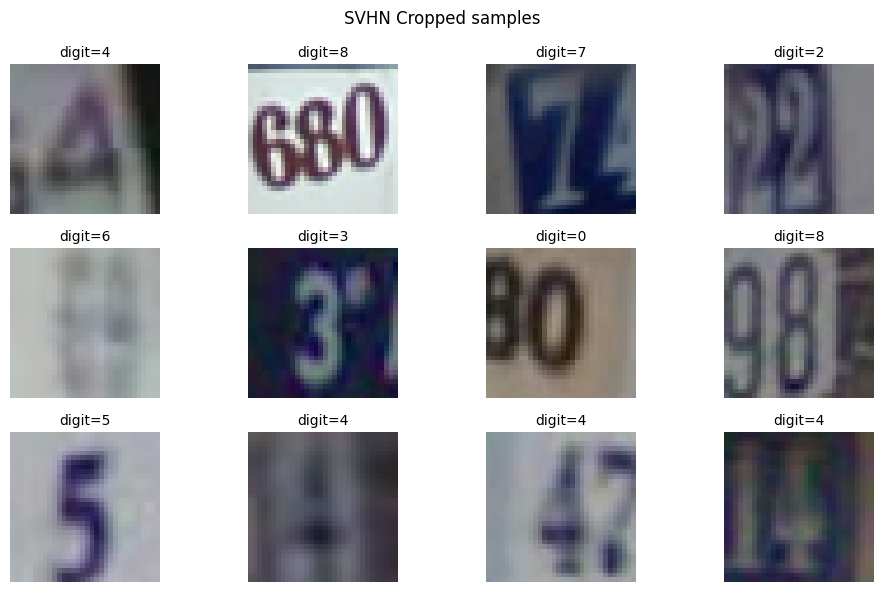

In [6]:
(ds_train_raw, ds_test_raw), info = tfds.load(
    "svhn_cropped",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

num_classes = info.features["label"].num_classes
print("num_classes:", num_classes)
print("train examples:", info.splits["train"].num_examples)
print("test  examples:", info.splits["test"].num_examples)

plt.figure(figsize=(10,6))
for i, (img, lab) in enumerate(ds_train_raw.take(12)):
    plt.subplot(3,4,i+1)
    plt.imshow(img.numpy())
    plt.title(f"digit={int(lab.numpy())}", fontsize=10)
    plt.axis("off")
plt.suptitle("SVHN Cropped samples")
plt.tight_layout()
plt.show()


## 2) 切分 Train / Val / Test + 前處理 + tf.data pipeline（加速）

In [7]:
TRAIN_EX = info.splits["train"].num_examples
VAL_EX = int(TRAIN_EX * 0.1)

ds_train_shuf = ds_train_raw.shuffle(TRAIN_EX, seed=SEED, reshuffle_each_iteration=False)
ds_val_raw = ds_train_shuf.take(VAL_EX)
ds_train_raw2 = ds_train_shuf.skip(VAL_EX)

IMG_SIZE = (96, 96)     # resize 以便 MobileNetV2 使用（且比 224 快）
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(img, label):
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.int32)

def prep(ds, shuffle=False):
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(4096, seed=SEED, reshuffle_each_iteration=True)
    return ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

ds_train = prep(ds_train_raw2, shuffle=True)
ds_val   = prep(ds_val_raw)
ds_test  = prep(ds_test_raw)

print("Train/Val/Test prepared ✅")


Train/Val/Test prepared ✅


## 3) 模型：MobileNetV2 Transfer Learning（第一階段：凍結 backbone）

In [8]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="augmentation")

def build_model(lr=1e-3, fine_tune_at=None, dropout=0.2):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = augmentation(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    if fine_tune_at is not None:
        base.trainable = True
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr/10),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
    return model

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]


## 4) 訓練（第一階段：Freeze）

In [9]:
EPOCHS_STAGE1 = 5

model = build_model(lr=1e-3, fine_tune_at=None, dropout=0.2)
model.summary()

hist1 = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks,
    verbose=2
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
516/516 - 646s - 1s/step - accuracy: 0.3638 - loss: 1.8408 - val_accuracy: 0.5263 - val_loss: 1.4210 - learning_rate: 1.0000e-03
Epoch 2/5
516/516 - 563s - 1s/step - accuracy: 0.4666 - loss: 1.5586 - val_accuracy: 0.5555 - val_loss: 1.3291 - learning_rate: 1.0000e-03
Epoch 3/5
516/516 - 560s - 1s/step - accuracy: 0.4894 - loss: 1.4997 - val_accuracy: 0.5809 - val_loss: 1.2808 - learning_rate: 1.0000e-03
Epoch 4/5
516/516 - 572s - 1s/step - accuracy: 0.4979 - loss: 1.4801 - val_accuracy: 0.5790 - val_loss: 1.2679 - learning_rate: 1.0000e-03
Epoch 5/5
516/516 - 569s - 1s/step - accuracy: 0.5020 - loss: 1.4634 - val_accuracy: 0.5873 - val_loss: 1.2477 - learning_rate: 1.0000e-03
Restoring model weights from the end of the best epoch: 5.


## 5) Fine-tuning（第二階段：解凍部分層）

In [10]:
EPOCHS_STAGE2 = 5
FINE_TUNE_AT = 100

ft_model = build_model(lr=1e-3, fine_tune_at=FINE_TUNE_AT, dropout=0.2)

hist2 = ft_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks,
    verbose=2
)


Epoch 1/5
516/516 - 956s - 2s/step - accuracy: 0.6422 - loss: 1.0650 - val_accuracy: 0.3409 - val_loss: 2.3686 - learning_rate: 1.0000e-04
Epoch 2/5
516/516 - 938s - 2s/step - accuracy: 0.8069 - loss: 0.5916 - val_accuracy: 0.4984 - val_loss: 1.6350 - learning_rate: 1.0000e-04
Epoch 3/5
516/516 - 945s - 2s/step - accuracy: 0.8493 - loss: 0.4682 - val_accuracy: 0.6695 - val_loss: 1.2359 - learning_rate: 1.0000e-04
Epoch 4/5
516/516 - 1000s - 2s/step - accuracy: 0.8701 - loss: 0.4018 - val_accuracy: 0.7921 - val_loss: 0.7656 - learning_rate: 1.0000e-04
Epoch 5/5
516/516 - 943s - 2s/step - accuracy: 0.8862 - loss: 0.3541 - val_accuracy: 0.8334 - val_loss: 0.5638 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.


## 6) 測試集評估 + 混淆矩陣

In [ ]:
test_loss, test_acc = ft_model.evaluate(ds_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

y_true, y_pred = [], []
for x, y in ds_test:
    p = ft_model.predict(x, verbose=0)
    y_true.extend(y.numpy().tolist())
    y_pred.extend(np.argmax(p, axis=1).tolist())

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix (SVHN digits)")
plt.xlabel("Pred")
plt.ylabel("True")
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar()
plt.tight_layout()
plt.show()